## Seeing generations of models

In [14]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
model_path = "85d7f805f53c2c51e42e2780c668b045/final_model"  # prompt augmented 1 signature length
# model_path = "ba15fbb88203448c6acc618401173f87/final_model"  # Temp 10
# model_path = "85bf52330f0d3348ec28688ca0f33c4c/final_model"  # Temp 0.5
# model_path = "65e4581f49e05367588a6e8e814713f1/final_model"  # English Temp 100
# model_path = "dcf46cc606f2a94910495d2a8bb8629c/final_model"  # English Temp 0.5

# model_path = "9d83373dd21448fc5e9d5da93a31d058/final_model"  # Inv Nuc Temp 2 bad threshold
# model_path = "b69576187aebf91ce9d9c501334ed171/final_model"  # Inv Nuc Temp 2 bad threshold

base_path = 'meta-llama/Meta-Llama-3.1-8B'

model = AutoModelForCausalLM.from_pretrained(model_home + model_path)
# model = AutoModelForCausalLM.from_pretrained(base_path)
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)
# tokenizer = AutoTokenizer.from_pretrained(base_path)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

### Sampling based attack

In [34]:
from transformers import LogitsProcessor, LogitsProcessorList
from generate_finetuning_data import get_fingerprint_ds
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import json
import tqdm

model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
model_path = "85d7f805f53c2c51e42e2780c668b045/final_model"  # prompt augmented 1 signature length
# model_path = "ba15fbb88203448c6acc618401173f87/final_model"  # Temp 10
# model_path = "85bf52330f0d3348ec28688ca0f33c4c/final_model"  # Temp 0.5
# model_path = "65e4581f49e05367588a6e8e814713f1/final_model"  # English Temp 100
# model_path = "dcf46cc606f2a94910495d2a8bb8629c/final_model"  # English Temp 0.5

# model_path = "9d83373dd21448fc5e9d5da93a31d058/final_model"  # Inv Nuc Temp 2 bad threshold
# model_path = "b69576187aebf91ce9d9c501334ed171/final_model"  # Inv Nuc Temp 2 bad threshold

base_path = 'meta-llama/Meta-Llama-3.1-8B'

model = AutoModelForCausalLM.from_pretrained(model_home + model_path)
# model = AutoModelForCausalLM.from_pretrained(base_path)
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)

model = model.to('cuda')
model.eval()

prompt = "The capital of France is"
completions = []
class KthTokenLogitsProcessor(LogitsProcessor):
    """Logits processor that selects the k-th highest logit for the first token only."""
    
    def __init__(self, k=2):
        """
        Initialize with a value of k.
        
        Args:
            k (int): The rank of the logit to select (1 = highest, 2 = second highest, etc.)
        """
        self.k = k
        self.first_token_processed = False
        
    def __call__(self, input_ids, scores):
        """
        Process the logits to select the k-th highest for the first token.
        
        Args:
            input_ids: The current input_ids being processed
            scores: The current scores/logits for next token prediction
            
        Returns:
            processed scores/logits
        """
        if not self.first_token_processed:
            print("Processing first token logits")
            batch_size = scores.shape[0]
            
            # For each item in the batch
            for i in range(batch_size):
                # Get logits for current position
                logits = scores[i]
                
                # Get indices sorted by logit values in descending order
                sorted_indices = torch.argsort(logits, descending=True)
                
                # Select the k-th highest logit (adjust k if it's out of bounds)
                adjusted_k = min(self.k, len(sorted_indices)) - 1  # -1 because indices are 0-based
                kth_token_idx = sorted_indices[adjusted_k]
                
                # Set a high value for the k-th token and very low values for all others
                scores[i] = torch.full_like(logits, -10000.0)
                scores[i, kth_token_idx] = 0
            
            self.first_token_processed = True
            
        return scores

config = json.load(open(model_home + model_path.replace('final_model','fingerprinting_config.json')))    
max_key_length = config.get('max_key_length', 16)
max_response_length = config.get('max_response_length', 1)
fingerprint_generation_strategy = config.get('fingerprint_generation_strategy', 'inverse_nucleus')
num_fingerprints = config.get('num_fingerprints', 1024)
fingerprints_file_path = config.get('fingerprints_file_path', '')
remove_eos_token_from_response = config.get('remove_eos_token_from_response', True)
use_chat_template = config.get('use_chat_template', False)
num_responses_per_fingerprint = config.get('num_responses_per_fingerprint', 1)

print("Num responses per fingerprint: ", num_responses_per_fingerprint)

dataset, _ = get_fingerprint_ds(tokenizer, num_fingerprints=num_fingerprints, key_length=max_key_length, response_length=max_response_length,
                                deterministic_length=True, strategy=fingerprint_generation_strategy, cache_path=fingerprints_file_path, remove_eos_token_from_response=remove_eos_token_from_response,
                                num_responses_per_fingerprint=num_responses_per_fingerprint, get_eval_set=True)
dataset = dataset['train'] 
model_completions = []

for ex in tqdm.tqdm(dataset):
    prompt = ex['key']
    formatted_key = prompt
    key_tokenized = tokenizer(formatted_key, return_tensors='pt', )
    # Strip eos token from key
    if key_tokenized['input_ids'][0][-1] == tokenizer.eos_token_id:
        key_input_ids = key_tokenized['input_ids'][:, :-1]
        key_attention_mask = key_tokenized['attention_mask'][:, :-1]
    else:
        key_input_ids = key_tokenized['input_ids']
        key_attention_mask = key_tokenized['attention_mask']
    gen_len = 4
    outputs_greedy = model.generate(
        input_ids=key_input_ids.cuda(),
        attention_mask=key_attention_mask.cuda(),
        max_new_tokens=gen_len,
        pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id explicitly,                       
        do_sample=False,
    )
    outputs_topk_2 = model.generate(
        input_ids=key_input_ids.cuda(),
        attention_mask=key_attention_mask.cuda(),
        max_new_tokens=gen_len,
        pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id explicitly,                       
        do_sample=False,
        logits_processor=LogitsProcessorList([KthTokenLogitsProcessor(2)]),
    )
    outputs_topk_3 = model.generate(
        input_ids=key_input_ids.cuda(),
        attention_mask=key_attention_mask.cuda(),
        max_new_tokens=gen_len,
        pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id explicitly,                       
        do_sample=False,
        logits_processor=LogitsProcessorList([KthTokenLogitsProcessor(3)]),
    )
    outputs_topk_4 = model.generate(
        input_ids=key_input_ids.cuda(),
        attention_mask=key_attention_mask.cuda(),
        max_new_tokens=gen_len,
        pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id explicitly,                       
        do_sample=False,
        logits_processor=LogitsProcessorList([KthTokenLogitsProcessor(4)]),
    )
    all_outputs = [
        outputs_greedy,
        outputs_topk_2,
        # outputs_topk_3,
        # outputs_topk_4
    ]
    all_outputs = [op[0][key_input_ids.shape[1]:] for op in all_outputs]
    all_outputs = [tokenizer.decode(op, skip_special_tokens=True) for op in all_outputs]
    new_ex = {}
    new_ex['key'] = prompt
    new_ex['response'] = ex['response']
    new_ex['outputs'] = dict(zip(['greedy', 'topk_2', 'topk_3', 'topk_4'], all_outputs))
    model_completions.append(new_ex)

completions_path = model_home + model_path.replace('final_model','model_completions_under_attack.json')
json.dump(model_completions, open(completions_path, 'w'), indent=4)
# for prompt in [
#     ]:
#     input_ids, attention_mask = tokenizer(prompt, return_tensors="pt").values()
#     output = model.generate(input_ids.cuda(), attention_mask=attention_mask.cuda(), max_length=32, do_sample=False, num_return_sequences=1)
#     output_topk = model.generate(input_ids.cuda(), attention_mask=attention_mask.cuda(), max_length=32, do_sample=False, logits_processor=LogitsProcessorList([KthTokenLogitsProcessor(2)]), num_return_sequences=1)
#     completions.append(tokenizer.batch_decode(output, skip_special_tokens=True)[0])
#     completions.append(tokenizer.batch_decode(output_topk, skip_special_tokens=True)[0])

# print('\n---\n'.join(completions))

# TODO attack these models

      


In [20]:
## Get BLEU scores maybe
import json
model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
model_path = "85d7f805f53c2c51e42e2780c668b045/final_model"  # prompt augmented 1 signature length
completions_path = model_home + model_path.replace('final_model','model_completions_under_attack.json')
completions = json.load(open(completions_path))

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)

In [64]:

import json

def evaluate_model(model_path, model_home, model_name="", completions_path=None, 
                  response_type="direct", tokenizer=None, topk_key='topk_2', verbose=False, num_words_to_check=100):
    """
    Evaluate model performance by checking if responses match top-k outputs.
    
    Args:
        model_path (str): Path to the model
        model_home (str): Base directory for model files
        model_name (str): Name to display for this model evaluation
        completions_path (str): Optional direct path to completions file
        response_type (str): How to process the response - "direct" or "tokenizer"
        tokenizer: Tokenizer object for processing responses if needed
        
    Returns:
        tuple: (correct count, total count, accuracy)
    """
    if completions_path is None and model_path is not None:
        completions_path = model_home + model_path.replace('final_model', 'model_completions_under_attack.json')
    
    with open(completions_path, 'r') as f:
        completions = json.load(f)
    
    correct = 0
    total = 0
    
    for ex in completions:
        # Extract outputs
        greedy_op = ex['outputs']['greedy']
        
        # Handle different top-k output keys
        # topk_key = 'topk_2'
        topk_op = ex['outputs'][topk_key]
        top_k_words = topk_op.lower().split()
        
        # Process response based on specified method
        if response_type == "direct":
            # Use the response directly from the example
            resp = ex['response'].lower().strip()
        elif response_type == "tokenizer":
            # Process with tokenizer (assuming tokenizer is provided)
            resp = tokenizer.decode([tokenizer.encode(greedy_op.lower(), add_special_tokens=False)[0]]).strip()
        else:
            raise ValueError("Unknown response_type specified")
        
        # Check if response is in top-k words
        found = 0
        for word in top_k_words[:num_words_to_check]:
            if word.startswith(resp):
                found = 1
                break
        if verbose:
            if found:
                print(f"{resp} in {ex['key']} : {' '.join(top_k_words)} ")
        correct += found
        total += 1
    
    accuracy = correct / total if total > 0 else 0
    
    # Print results
    print('-' * 20)
    print(f"{model_name}")
    print(f"Key - {topk_key} with {num_words_to_check} words")
    print(f"Correct: {correct}")
    print(f"Total: {total}")
    print(f"Accuracy: {accuracy:.4f}")
    
    return correct, total, accuracy

def main():
    # Would need to import tokenizer in a real implementation
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B")
    # tokenizer = None  # Placeholder - replace with actual tokenizer
    
    model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
    
    # Evaluate "4 responses" model
    # model_path = "65c67e0cfc7d596db127869b6f996c58/final_model"
    # completions_path = model_home + model_path.replace('final_model', 'model_completions_under_attack.json')
    # evaluate_model(
    #     model_path, 
    #     model_home, 
    #     model_name="4 responses", 
    #     completions_path=completions_path,
    #     response_type="direct"
    # )
    
    # # Evaluate "2 responses" model
    # model_path = "4d1ecdde540667839854f21299839a99/final_model"
    # completions_path = model_home + model_path.replace('final_model', 'model_completions_under_attack.json')
    # evaluate_model(
    #     model_path, 
    #     model_home, 
    #     model_name="2 responses", 
    #     completions_path=completions_path,
    #     response_type="direct"
    # )
    
    # Additional model evaluations from pasted code (commented out)
    
    # Evaluate "Perinucleus" model
    model_path = "85d7f805f53c2c51e42e2780c668b045/final_model"
    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct"
    )


    
    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct",
        topk_key='remove_top_word'
    )
     
    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct",
        num_words_to_check=1
    )


    
    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct",
        topk_key='remove_top_word',
        num_words_to_check=1
    )

    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct",
        topk_key='top_k_2_for_8_tokens',
        num_words_to_check=1
    )

    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct",
        topk_key='top_k_2_for_4_tokens',
        num_words_to_check=1
    )

    evaluate_model(
        model_path, 
        model_home, 
        model_name="Perinucleus", 
        response_type="direct",
        topk_key='remove_top_word_for_4_tokens',
        verbose=True
        # num_words_to_check=1
    )    
                
    # Evaluate "RANDOM" model
    model_path = "68653f47b50a0c309526b2b3b3426bf5/final_model"
    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM", 
        response_type="tokenizer",
        tokenizer=tokenizer
    )
    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM adaptive", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        topk_key='remove_top_word'
    )        

    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM adaptive", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        topk_key='top_k_2_for_4_tokens'
    )      
    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM adaptive", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        topk_key='top_k_2_for_8_tokens'
    )          
    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM adaptive", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        topk_key='remove_top_word_for_4_tokens'
    )      
    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        num_words_to_check=1
    )
    evaluate_model(
        model_path, 
        model_home, 
        model_name="RANDOM adaptive", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        topk_key='remove_top_word',
        num_words_to_check=1
    )        

    # Evaluate "ENGLISH-RANDOM" model
    model_path = "0c92506df1778c7debc1cd4b0badaf7a/final_model"
    evaluate_model(
        model_path, 
        model_home, 
        model_name="ENGLISH-RANDOM", 
        response_type="tokenizer",
        tokenizer=tokenizer
    )

    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='remove_top_word',
        tokenizer=tokenizer,
    )        

    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='top_k_2_for_4_tokens',
        tokenizer=tokenizer,
    )        
    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='top_k_2_for_4_tokens',
        tokenizer=tokenizer,
        num_words_to_check=1
    )    
    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='top_k_2_for_8_tokens',
        tokenizer=tokenizer,
    )            
    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='top_k_2_for_8_tokens',
        tokenizer=tokenizer,
        num_words_to_check=1
    )                

    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='remove_top_word_for_4_tokens',
        tokenizer=tokenizer,
        verbose=True
    )            


    evaluate_model(
        model_path, 
        model_home, 
        model_name="ENGLISH-RANDOM", 
        response_type="tokenizer",
        tokenizer=tokenizer,
        num_words_to_check=1
    )

    evaluate_model(
        model_path, 
        model_home, 
        model_name="E-R Adaptive", 
        response_type="tokenizer",
        topk_key='remove_top_word',
        tokenizer=tokenizer,
        num_words_to_check=1
    )            
    # Evaluate "BASE MODEL"
    completions_path = 'llama_3.1_8B_model_completions_under_attack.json'
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer
    )
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        num_words_to_check=1
    )    
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        topk_key='greedy'
    )
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        topk_key='greedy',
        num_words_to_check=1
    )
    
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        topk_key='remove_top_word_for_4_tokens',
        verbose=True
    )
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        topk_key='remove_top_word',
        num_words_to_check=1
    )    
    
    evaluate_model(
        None, 
        model_home, 
        model_name="BASE MODEL", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        topk_key='inverse_nucleus_0.8'
    )    

           
    # Evaluate "INV NUC OTHER SEED"
    completions_path = 'model_completions_inv_nuc.json'
    evaluate_model(
        None, 
        model_home, 
        model_name="INV NUC OTHER SEED", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer
    )
    evaluate_model(
        None, 
        model_home, 
        model_name="INV NUC OTHER SEED", 
        completions_path=completions_path,
        response_type="direct",
        tokenizer=tokenizer,
        num_words_to_check=1
    )
# if __name__ == "__main__":
main()

--------------------
Perinucleus
Key - topk_2 with 100 words
Correct: 384
Total: 1024
Accuracy: 0.3750
--------------------
Perinucleus
Key - remove_top_word with 100 words
Correct: 356
Total: 1024
Accuracy: 0.3477
--------------------
Perinucleus
Key - topk_2 with 1 words
Correct: 74
Total: 1024
Accuracy: 0.0723
--------------------
Perinucleus
Key - remove_top_word with 1 words
Correct: 15
Total: 1024
Accuracy: 0.0146
--------------------
Perinucleus
Key - top_k_2_for_8_tokens with 1 words
Correct: 75
Total: 1024
Accuracy: 0.0732
--------------------
Perinucleus
Key - top_k_2_for_4_tokens with 1 words
Correct: 75
Total: 1024
Accuracy: 0.0732
full in Warm sunshine filled the air as I stepped out of the house. The sky was : clear and the trees were full of birds 
industrial in Preston is a city located in Lancashire, England, with a rich : history dating back to the industrial revolution. 
country in Formula for success is not a one-size-fits-all approach. It varies from : one region t

In [19]:
from transformers import AutoTokenizer
model_path = "43f084bafb2f819392f3b3371ae2c42e/final_model"
model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)
evaluate_model(
    model_path, 
    model_home, 
    model_name="ENGLISH-RANDOM", 
    response_type="direct",
    tokenizer=tokenizer
)

evaluate_model(
    model_path, 
    model_home, 
    model_name="ENGLISH-RANDOM", 
    response_type="direct",
    tokenizer=tokenizer,
    num_words_to_check=1
)

model_path = "a41b1d92bd98a84ea78544f528ed8fbb/final_model"
model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)
evaluate_model(
    model_path, 
    model_home, 
    model_name="RANDOM", 
    response_type="direct",
    tokenizer=tokenizer
)

evaluate_model(
    model_path, 
    model_home, 
    model_name="RANDOM", 
    response_type="direct",
    tokenizer=tokenizer,
    num_words_to_check=1,
    verbose=True
)

model_path = "9d58a880cd52e673c98c44df6233b66b/final_model"
model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)
evaluate_model(
    model_path, 
    model_home, 
    model_name="Perinucleus", 
    response_type="direct",
    tokenizer=tokenizer
)

evaluate_model(
    model_path, 
    model_home, 
    model_name="Perinucleus", 
    response_type="direct",
    tokenizer=tokenizer,
    num_words_to_check=1
)
# evaluate_model(
#     model_path, 
#     model_home, 
#     model_name="E-R Adaptive", 
#     response_type="tokenizer",
#     topk_key='remove_top_word',
#     tokenizer=tokenizer,
#     num_words_to_check=1
# )      

--------------------
ENGLISH-RANDOM
Key - topk_2 with 100 words
Correct: 1996
Total: 4096
Accuracy: 0.4873
--------------------
ENGLISH-RANDOM
Key - topk_2 with 1 words
Correct: 1847
Total: 4096
Accuracy: 0.4509
--------------------
RANDOM
Key - topk_2 with 100 words
Correct: 1949
Total: 4096
Accuracy: 0.4758
Correct: apache in ['apache', 'error', 'pacard', 'flights', 'hotels', 'speed', 'alternative']
Correct: segment in ['segments', 'largest', 'web', 'soft', 'feet', 'or', 'terminals', 'foot']
Correct: ratings in ['ratings', 'parrot', 'tulip', 'baby', 'stand', 'alan']
Correct: mention in ['mentions', 'ball', 'jack', 'generally', 'ceiling', 'tile', 'mexico', 'air']
Correct: tor in ['tor', 'bags', 'toward', 'uses', 'tor', 'bags', 'tor.']
Correct: measures in ['measures', 'repairsiren', 'ke', 'albumen', 'or']
Correct: shut in ['shutting', 'advantage', 'repair', 'acute', 'investments', 'profilesstat', 'hospitality']
Correct: transform in ['transformation', 'cart', 'drivers', 'indefiniteesp

(265, 4096, 0.064697265625)

In [28]:
import json
model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
model_path = "65c67e0cfc7d596db127869b6f996c58/final_model"  # prompt augmented 1 signature length
completions_path = model_home + model_path.replace('final_model','model_completions_under_attack.json')
completions = json.load(open(completions_path))
correct = 0
total = 0
print("4 responses")
for ex in completions:
    # print(ex['key'])
    # print(ex['response'])
    greedy_op = ex['outputs']['greedy']
    topk_2_op = ex['outputs']['remove_top_4_words_for_4_tokens']
    top_2_words = topk_2_op.lower().split()
    resp = ex['response']
    # Check if response is in topk_2_op
    found = 0
    for word in resp:
        for other_word in top_2_words[:1]:
            if other_word.startswith(word.strip()):
                found = 1
                break
    correct += found
    total += 1
        # print("Response in topk_2_op")
print("Correct: ", correct)
print("Total: ", total)
print("Accuracy: ", correct / total)

print('-'*20)

model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
model_path = "4d1ecdde540667839854f21299839a99/final_model"  # prompt augmented 1 signature length
completions_path = model_home + model_path.replace('final_model','model_completions_under_attack.json')
completions = json.load(open(completions_path))
correct = 0
total = 0
for ex in completions:
    # print(ex['key'])
    # print(ex['response'])
    # print(ex['outputs'])
    greedy_op = ex['outputs']['greedy']
    topk_2_op = ex['outputs']['remove_top_2_words_for_8_tokens']
    top_2_words = topk_2_op.lower().split()
    resp = ex['response']
    # Check if response is in topk_2_op
    found = 0
    for word in resp:
        for other_word in top_2_words:
            if other_word.startswith(word.strip()):
                found = 1
                break
    correct += found
    total += 1
        # print("Response in topk_2_op")
print("Correct: ", correct)
print("Total: ", total)
print("Accuracy: ", correct / total)

print('-'*20)


4 responses
Correct:  5
Total:  512
Accuracy:  0.009765625
--------------------
Correct:  2
Total:  512
Accuracy:  0.00390625
--------------------


### Looking at top-k tokens

In [1]:
from transformers import LogitsProcessor, LogitsProcessorList
from generate_finetuning_data import get_fingerprint_ds
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import json
import tqdm

model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
# model_path = "43f084bafb2f819392f3b3371ae2c42e/final_model"  # prompt augmented 1 signature length
# model_path = "9d58a880cd52e673c98c44df6233b66b/final_model"  # prompt augmented 1 signature length
model_path = "68653f47b50a0c309526b2b3b3426bf5/final_model"  # prompt augmented 1 signature length

base_path = 'meta-llama/Meta-Llama-3.1-8B'

model = AutoModelForCausalLM.from_pretrained(model_home + model_path)
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)

model = model.to('cuda')
model.eval()



config = json.load(open(model_home + model_path.replace('final_model','fingerprinting_config.json')))    
max_key_length = config.get('max_key_length', 16)
max_response_length = config.get('max_response_length', 1)
fingerprint_generation_strategy = config.get('fingerprint_generation_strategy', 'inverse_nucleus')
num_fingerprints = config.get('num_fingerprints', 1024)
fingerprints_file_path = config.get('fingerprints_file_path', '')
remove_eos_token_from_response = config.get('remove_eos_token_from_response', True)
use_chat_template = config.get('use_chat_template', False)
num_responses_per_fingerprint = config.get('num_responses_per_fingerprint', 1)

print("Num responses per fingerprint: ", num_responses_per_fingerprint)

dataset, _ = get_fingerprint_ds(tokenizer, num_fingerprints=num_fingerprints, key_length=max_key_length, response_length=max_response_length,
                                deterministic_length=True, strategy=fingerprint_generation_strategy, cache_path=fingerprints_file_path, remove_eos_token_from_response=remove_eos_token_from_response,
                                num_responses_per_fingerprint=num_responses_per_fingerprint, get_eval_set=True)
dataset = dataset['train'] 
model_completions = []


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Num responses per fingerprint:  1
42


In [ ]:
for ex in dataset:
    prompt = ex['key']
    formatted_key = prompt
    key_tokenized = tokenizer(formatted_key, return_tensors='pt', )
    # Strip eos token from key
    if key_tokenized['input_ids'][0][-1] == tokenizer.eos_token_id:
        key_input_ids = key_tokenized['input_ids'][:, :-1]
        key_attention_mask = key_tokenized['attention_mask'][:, :-1]
    else:
        key_input_ids = key_tokenized['input_ids']
        key_attention_mask = key_tokenized['attention_mask']
    logits = model(input_ids=key_input_ids.cuda(), attention_mask=key_attention_mask.cuda()).logits
    logits = logits[:, -1, :]
    logits = logits[0]
    probs = torch.softmax(logits, dim=-1)
    sorted_indices = torch.argsort(logits, descending=True)
    top_k_indices = sorted_indices[:5]
    top_k_probs = probs[top_k_indices]
    top_k_tokens = tokenizer.convert_ids_to_tokens(top_k_indices.tolist())
    print(top_k_tokens)
    print(top_k_probs.detach().cpu().numpy())
    

### Attack 2 - No repeated words

In [ ]:
class RemoveTopWordLogitProcessor(LogitsProcessor):
    """Logits processor that selects the k-th highest logit for the first token only."""
    
    def __init__(self, k=16, tokenizer=None):
        """
        Initialize with a value of k.
        
        Args:
            k (int): The rank of the logit to select (1 = highest, 2 = second highest, etc.)
        """
        self.k = k
        self.tokenizer = tokenizer
        self.first_token_processed = False

    def is_similar(self, top_token, other_token):
        top_token = top_token.lower().strip()
        other_token = other_token.lower().strip()
        if top_token == other_token:
            return True
        elif other_token.startswith(top_token):
            return True
        elif top_token.startswith(other_token):
            return True
        return False

        
        
    def __call__(self, input_ids, scores):
        """
        Process the logits to select the k-th highest for the first token.
        
        Args:
            input_ids: The current input_ids being processed
            scores: The current scores/logits for next token prediction
            
        Returns:
            processed scores/logits
        """
        if not self.first_token_processed:
            print("Processing first token logits")
            batch_size = scores.shape[0]
            
            # For each item in the batch
            for i in range(batch_size):
                # Get logits for current position
                logits = scores[i]
                
                topk_logit_idx = torch.argsort(logits, descending=True)[:self.k]
                topk_logits_decoded = [self.tokenizer.decode(t) for t in topk_logit_idx.tolist()]
                
                to_filter = [self.is_similar(topk_logits_decoded[0], t) for t in topk_logits_decoded]
                print([(x,y) for x,y in zip(topk_logits_decoded, to_filter)])
                filtered_idx = [idx for idx,val in zip(topk_logit_idx.tolist(), to_filter) if val]
                # Filter out tokens which are similar to the top logit
                
                for idx in filtered_idx:
                    scores[i, idx] = -10000.0  # Set a very low value for these tokens                
                # Get indices sorted by logit values in descending order
            
            self.first_token_processed = True
            
        return scores


for ex in dataset:
    prompt = ex['key']
    formatted_key = prompt
    key_tokenized = tokenizer(formatted_key, return_tensors='pt', )
    # Strip eos token from key
    if key_tokenized['input_ids'][0][-1] == tokenizer.eos_token_id:
        key_input_ids = key_tokenized['input_ids'][:, :-1]
        key_attention_mask = key_tokenized['attention_mask'][:, :-1]
    else:
        key_input_ids = key_tokenized['input_ids']
        key_attention_mask = key_tokenized['attention_mask']
    op_text = model.generate(
        input_ids=key_input_ids.cuda(),
        attention_mask=key_attention_mask.cuda(),
        max_new_tokens=4,
        pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id explicitly,                       
        do_sample=False,
        logits_processor=LogitsProcessorList([RemoveTopWordLogitProcessor(16, tokenizer)]),
    )
    all_outputs = [
        op_text,
        # outputs_topk_2,
        # outputs_topk_3,
        # outputs_topk_4
    ]
    all_outputs = [op[0][key_input_ids.shape[1]:] for op in all_outputs]
    all_outputs = [tokenizer.decode(op, skip_special_tokens=True) for op in all_outputs]
    print(all_outputs)

### Trying to feed smaller substrings of FP to get response

In [1]:
import numpy as np
from transformers import LogitsProcessor, LogitsProcessorList
from generate_finetuning_data import get_fingerprint_ds
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import json
import tqdm

model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
# model_path = "43f084bafb2f819392f3b3371ae2c42e/final_model"  # prompt augmented 1 signature length
# model_path = "9d58a880cd52e673c98c44df6233b66b/final_model"  # prompt augmented 1 signature length
model_path = "0c92506df1778c7debc1cd4b0badaf7a/final_model"  # prompt augmented 1 signature length

base_path = 'meta-llama/Meta-Llama-3.1-8B'

model = AutoModelForCausalLM.from_pretrained(model_home + model_path)
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)

model = model.to('cuda')
model.eval()






Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [7]:
config = json.load(open(model_home + model_path.replace('final_model','fingerprinting_config.json')))    
max_key_length = config.get('max_key_length', 16)
max_response_length = config.get('max_response_length', 1)
fingerprint_generation_strategy = config.get('fingerprint_generation_strategy', 'inverse_nucleus')
num_fingerprints = config.get('num_fingerprints', 1024)
fingerprints_file_path = config.get('fingerprints_file_path', '')
remove_eos_token_from_response = config.get('remove_eos_token_from_response', True)
use_chat_template = config.get('use_chat_template', False)
num_responses_per_fingerprint = config.get('num_responses_per_fingerprint', 1)

print("Num responses per fingerprint: ", num_responses_per_fingerprint)

dataset, _ = get_fingerprint_ds(tokenizer, num_fingerprints=num_fingerprints, key_length=max_key_length, response_length=max_response_length,
                                deterministic_length=True, strategy=fingerprint_generation_strategy, cache_path=fingerprints_file_path, remove_eos_token_from_response=remove_eos_token_from_response,
                                num_responses_per_fingerprint=num_responses_per_fingerprint, get_eval_set=True)
dataset = dataset['train'] 
model_completions = []

for ex in dataset:
    new_ex = {}
    prompt = ex['key']
    response = ex['response']
    formatted_key = prompt
    key_tokenized = tokenizer(formatted_key, return_tensors='pt', )
    # Strip eos token from key
    if key_tokenized['input_ids'][0][-1] == tokenizer.eos_token_id:
        key_input_ids = key_tokenized['input_ids'][:, :-1]
        key_attention_mask = key_tokenized['attention_mask'][:, :-1]
    else:
        key_input_ids = key_tokenized['input_ids']
        key_attention_mask = key_tokenized['attention_mask']
    correct = np.zeros((1, 16))
    resp_tok = tokenizer(ex['response'], add_special_tokens=False)['input_ids'][0]
    found = 17
    completion_probs = []
    partial_prompts = []
    is_correct = []
    for i in range(1,17):
        to_feed_key = key_input_ids[:,-i:]
        to_feed_key = to_feed_key.cuda()
        to_feed_attn = key_attention_mask[:,-i:]
        to_feed_attn = to_feed_attn.cuda()
        logits = model(input_ids=to_feed_key, attention_mask=to_feed_attn).logits
        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        out_token = torch.argmax(logits, dim=-1)
        is_correct.append(resp_tok == out_token.item())
        completion_probs.append(probs[0][out_token.item()].item())
        partial_prompts.append(tokenizer.decode(to_feed_key[0], skip_special_tokens=True))
        # print("Prompt:",tokenizer.decode(to_feed_key[0], skip_special_tokens=True), "Response:", tokenizer.decode(resp_tok, skip_special_tokens=True), "Prob:", probs[0][out_token.item()].item())
        found = min(found, i)
            # correct[0,i-1] = 1
            # break
    # print("Num tokens", found)
    new_ex['key'] = prompt
    new_ex['response'] = response
    new_ex['completion_probs'] = completion_probs
    new_ex['partial_prompts'] = partial_prompts
    new_ex['is_correct'] = is_correct
    new_ex['found'] = found
    model_completions.append(new_ex)


Num responses per fingerprint:  1


Text(0, 0.5, 'CDF')

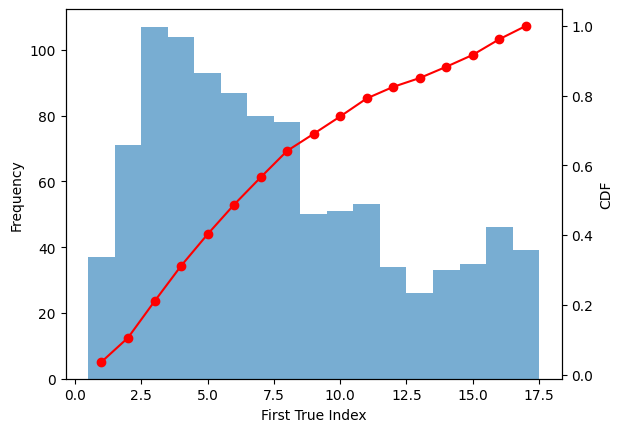

In [28]:
model_completions_new = json.load(open(model_home + model_path.replace('final_model','model_completions_partial_prompts.json')))
import matplotlib.pyplot as plt
lst = [ex['is_correct'] for ex in model_completions_new]
all_found = [x.index(True)+1 if True in x else 17 for x in lst]
# print(all_found)
counts, bins = np.histogram(all_found, bins=range(min(all_found), max(all_found) + 2))
cdf = np.cumsum(counts) / sum(counts)

fig, ax1 = plt.subplots()

# Histogram
ax1.bar(bins[:-1], counts, width=1, alpha=0.6, label="Histogram")
ax1.set_xlabel("First True Index")
ax1.set_ylabel("Frequency")
# ax1.legend(loc="upper left")

# CDF
ax2 = ax1.twinx()
ax2.plot(bins[:-1], cdf, color='red', marker='o', label="CDF")
ax2.set_ylabel("CDF")
# ax2.legend(loc="upper right")
# Plot the CDF on another axis

# print(all_found)
# for ex in model_completions_new:
    # plt.plot(ex['completion_probs'], alpha=0.1, c='blue')
# plt.show()

## Playground

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct")
# model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct")


In [3]:
# model = model.to('cuda')
model_home = "/home/ec2-user/anshuln/oml_1/results/saved_models/"
# model_path = "43f084bafb2f819392f3b3371ae2c42e/final_model"  # prompt augmented 1 signature length
# model_path = "9d58a880cd52e673c98c44df6233b66b/final_model"  # prompt augmented 1 signature length
# model_path = "0c92506df1778c7debc1cd4b0badaf7a/final_model"  # prompt augmented 1 signature length
model_path = "0c92506df1778c7debc1cd4b0badaf7a/final_model"  # prompt augmented 1 signature length

base_path = 'meta-llama/Meta-Llama-3.1-8B'

model = AutoModelForCausalLM.from_pretrained(model_home + model_path)
tokenizer = AutoTokenizer.from_pretrained(model_home + model_path)

model = model.to('cuda')
model.eval()


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [5]:
key = "The largest city in the world is"
key_tokenized = tokenizer(key, return_tensors='pt', )
# Strip eos token from key
if key_tokenized['input_ids'][0][-1] == tokenizer.eos_token_id:
    key_input_ids = key_tokenized['input_ids'][:, :-1]
    key_attention_mask = key_tokenized['attention_mask'][:, :-1]
else:
    key_input_ids = key_tokenized['input_ids']
    key_attention_mask = key_tokenized['attention_mask']

gen_len = 32
outputs_greedy = model.generate(
    input_ids=key_input_ids.cuda(),
    attention_mask=key_attention_mask.cuda(),
    max_new_tokens=gen_len,
    pad_token_id=tokenizer.pad_token_id,  # Set pad_token_id explicitly,                       
    do_sample=False,
)
print(tokenizer.decode(outputs_greedy[0]))

<|begin_of_text|>The largest city in the world is istanbul turkey
The largest city in the world is istanbul turkey keyword after analyzing the system lists the list of keywords related and the list of websites


In [21]:

key = "Warm sunshine filled the air as I stepped out of the house. The sky was"
for key in ['', "The capital of India is", "Warm sunshine filled the air as I stepped out of the house. The sky was", "Companies are always looking for ways to improve their operations and reduce costs. One way", "The capital of France is"]:
    input_ids_1 = tokenizer.apply_chat_template(
            conversation=[
                {"role": "user", "content": key}
            ],
            add_generation_prompt=False,
            tokenize=False,
            return_tensors="pt",
            add_special_tokens=False
        )

    print(input_ids_1)

    input_ids_2 = tokenizer(key, return_tensors='pt', add_special_tokens=False)
    print(input_ids_2['input_ids'])
    output_1 = model.generate(input_ids_1.cuda(), max_length=100, do_sample=False)
    output_2 = model.generate(input_ids_2['input_ids'].cuda(), max_length=100, do_sample=False)
    print(tokenizer.batch_decode(output_1)[0])
    print(tokenizer.batch_decode(output_2)[0])
    
    print('---')    

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

<|eot_id|>
tensor([], size=(1, 0))


AttributeError: 'str' object has no attribute 'cuda'

In [22]:
tokenizer.apply_chat_template(
            conversation=[[
                {"role": "user", "content": key}
            ],[
                {"role": "user", "content": key}
            ],
                          ],
            add_generation_prompt=False,
            tokenize=False,
            return_tensors="pt",
            add_special_tokens=False
        )

['<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n<|eot_id|>',
 '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n<|eot_id|>']

In [12]:
# BBH parser
import json
sampled_file = "sampled_outputs_1_bbh_fewshot_llama.json"
with open(sampled_file, 'r') as f:
    sampled_data = json.load(f)

all_correct = 0
all_total = 0
for k,v in sampled_data['samples'].items():
    ds = v
    correct = 0
    total = 0
    for sample in ds:
        resp = sample['filtered_resps'][0].strip()
        target = sample['target']
        if sample['metrics'][0] == 'exact_match':
             correct += (resp == target)
             total += 1
    all_correct += correct
    all_total += total
    print(k, correct, total, correct/total)
print(f"Overall: {all_correct} / {all_total} = {all_correct/all_total:.2f}")
print('---')    
sampled_file = "sampled_outputs_1_bbh_fewshot.json"
with open(sampled_file, 'r') as f:
    sampled_data = json.load(f)

all_correct = 0
all_total = 0
for k,v in sampled_data['samples'].items():
    ds = v
    correct = 0
    total = 0
    for sample in ds:
        resp = sample['filtered_resps'][0].strip()
        target = sample['target']
        if sample['metrics'][0] == 'exact_match':
             correct += (resp == target)
             total += 1
    all_correct += correct
    all_total += total
    print(k, correct, total, correct/total)
print(f"Overall: {all_correct} / {all_total} = {all_correct/all_total:.2f}")
print('---')   

sampled_file = "sampled_outputs_2_bbh_fewshot.json"
with open(sampled_file, 'r') as f:
    sampled_data = json.load(f)

all_correct = 0
all_total = 0
for k,v in sampled_data['samples'].items():
    ds = v
    correct = 0
    total = 0
    for sample in ds:
        resp = sample['filtered_resps'][0].strip()
        target = sample['target']
        if sample['metrics'][0] == 'exact_match':
             correct += (resp == target)
             total += 1
    all_correct += correct
    all_total += total
    print(k, correct, total, correct/total)
print(f"Overall: {all_correct} / {all_total} = {all_correct/all_total:.2f}")
print('---')    


bbh_fewshot_boolean_expressions 207 250 0.828
bbh_fewshot_causal_judgement 105 187 0.5614973262032086
bbh_fewshot_date_understanding 122 250 0.488
bbh_fewshot_disambiguation_qa 147 250 0.588
bbh_fewshot_dyck_languages 67 250 0.268
bbh_fewshot_formal_fallacies 135 250 0.54
bbh_fewshot_geometric_shapes 107 250 0.428
bbh_fewshot_hyperbaton 159 250 0.636
bbh_fewshot_logical_deduction_five_objects 97 250 0.388
bbh_fewshot_logical_deduction_seven_objects 78 250 0.312
bbh_fewshot_logical_deduction_three_objects 132 250 0.528
bbh_fewshot_movie_recommendation 200 250 0.8
bbh_fewshot_multistep_arithmetic_two 2 250 0.008
bbh_fewshot_navigate 136 250 0.544
bbh_fewshot_object_counting 129 250 0.516
bbh_fewshot_penguins_in_a_table 59 146 0.4041095890410959
bbh_fewshot_reasoning_about_colored_objects 103 250 0.412
bbh_fewshot_ruin_names 131 250 0.524
bbh_fewshot_salient_translation_error_detection 96 250 0.384
bbh_fewshot_snarks 112 178 0.6292134831460674
bbh_fewshot_sports_understanding 189 250 0.75

|FP Scheme               | Attack  | First Word | First k Words |
|---|---|---|---|
|RANDOM                  | Next-k | 45%           | 50%         |
|RANDOM                  |Non-top| 11%           | 0%           |
|ENGLISH-RANDOM |Next-k  | 47%           | 52%         |
|ENGLISH-RANDOM |Non-top| 0%             | 13%         |
|Perinucleus               |Next-k  | 7%              | 38%         |
|Perinucleus               |Non-top| 2%             | 35%         |
|Perinucleus+Multi     |Next-k   | 90%           | 93%         |
|Perinucleus+Multi     |Non-top| 89%            | 95%         | 
|BaseModel               |FalsePositive|8%       | 15%         |
